
# Ensemble Learning on Imbalanced Data
# Credit Card Fraud Detection
https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud?resource=download




# Install Required Libraries:

In [1]:
!pip install imbalanced-learn xgboost

# Import Libraries:

In [2]:
import pandas as pd
import numpy as np
import time

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier

from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks

from xgboost import XGBClassifier

# Load data:

In [3]:
df = pd.read_csv("creditcard.csv")

df.head()

/tmp/ipykernel_1403/2595635376.py:1: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("creditcard.csv")


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


**Dataset Overview:**

Dataset Shape: (33760, 31)

Class Distribution:
Class
0.0    33656
1.0      103
Name: count, dtype: int64


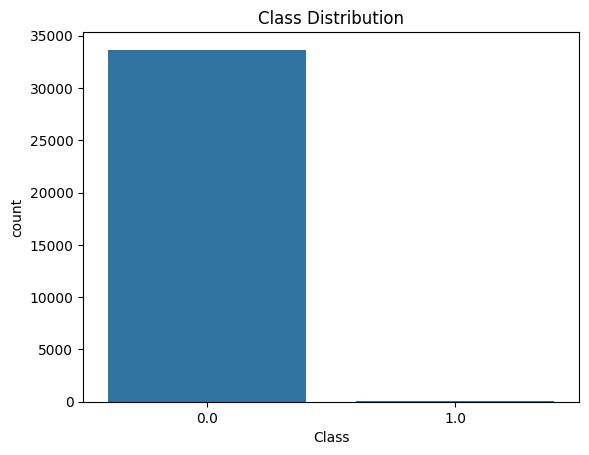

In [4]:
print("Dataset Shape:", df.shape)

print("\nClass Distribution:")
print(df['Class'].value_counts())

sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.show()

**Prepare Data:**

In [6]:
df.dropna(subset=['Class'], inplace=True)
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Phase 1 — Baseline Model:

In [7]:
baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:,1]

print("Baseline Model Results\n")
print(classification_report(y_test, y_pred))

roc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc)

Baseline Model Results

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      6731
         1.0       0.54      0.62      0.58        21

    accuracy                           1.00      6752
   macro avg       0.77      0.81      0.79      6752
weighted avg       1.00      1.00      1.00      6752

ROC-AUC: 0.9688505917892338


# **Accuracy Problem Explanation:**
In imbalanced datasets, accuracy can be misleading.

If 99% of transactions are normal,
a model predicting all transactions as normal
will still achieve ~99% accuracy but detect zero fraud.

Therefore we focus on:
Precision
Recall
F1-score
ROC-AUC

# **Phase 2 — Sampling Techniques:**

**Evaluation function:**

In [10]:
def evaluate_sampling(sampler, name):

    start = time.time()

    X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_resampled, y_resampled)

    y_pred = model.predict(X_test)

    report = classification_report(y_test, y_pred, output_dict=True)
    precision = report['1.0']['precision']
    recall = report['1.0']['recall']
    f1 = report['1.0']['f1-score']

    training_time = time.time() - start

    return {
        "Technique": name,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Training Time": training_time
    }

**Apply Sampling:**

In [11]:
results_sampling = []

ros = RandomOverSampler()
rus = RandomUnderSampler()
smote = SMOTE()
tomek = TomekLinks()

results_sampling.append(evaluate_sampling(ros, "Random Oversampling"))
results_sampling.append(evaluate_sampling(rus, "Random Undersampling"))
results_sampling.append(evaluate_sampling(smote, "SMOTE"))
results_sampling.append(evaluate_sampling(tomek, "Tomek Links"))

sampling_results_df = pd.DataFrame(results_sampling)

sampling_results_df

,Technique,Precision,Recall,F1-score,Training Time
0,Random Oversampling,0.184783,0.809524,0.300885,0.823048
1,Random Undersampling,0.156522,0.857143,0.264706,0.091502
2,SMOTE,0.202532,0.761905,0.320000,0.872054
3,Tomek Links,0.521739,0.571429,0.545455,6.898401


# **Phase 3 — Ensemble Models:**

**Evaluation Function:**

In [14]:
def evaluate_model(model, name):

    start = time.time()

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    report = classification_report(y_test, y_pred, output_dict=True)
    precision = report['1.0']['precision']
    recall = report['1.0']['recall']
    f1 = report['1.0']['f1-score']

    training_time = time.time() - start

    return {
        "Model": name,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Training Time": training_time
    }

**Train Ensemble Models:**

In [15]:
ensemble_results = []

rf = RandomForestClassifier(n_estimators=200)

gb = GradientBoostingClassifier()

xgb = XGBClassifier(scale_pos_weight=10)

stack = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier()),
        ('gb', GradientBoostingClassifier())
    ],
    final_estimator=LogisticRegression()
)

ensemble_results.append(evaluate_model(rf, "Random Forest"))
ensemble_results.append(evaluate_model(gb, "Gradient Boosting"))
ensemble_results.append(evaluate_model(xgb, "XGBoost"))
ensemble_results.append(evaluate_model(stack, "Stacking Classifier"))

ensemble_results_df = pd.DataFrame(ensemble_results)

ensemble_results_df

,Model,Precision,Recall,F1-score,Training Time
0,Random Forest,0.937500,0.714286,0.810811,29.820091
1,Gradient Boosting,0.833333,0.714286,0.769231,66.808127
2,XGBoost,0.888889,0.761905,0.820513,1.251234
3,Stacking Classifier,0.937500,0.714286,0.810811,371.260335


# **Phase 4 — Deep Analysis:**

**Confusion Matrix for Best Model:**

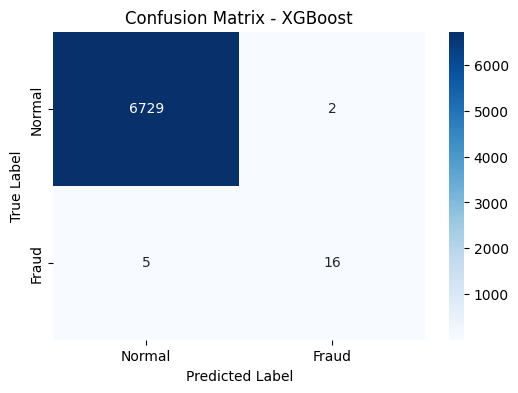

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

best_model = XGBClassifier(scale_pos_weight=10)

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal","Fraud"],
    yticklabels=["Normal","Fraud"]
)

plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

The confusion matrix shows that the model successfully detects most fraudulent transactions while maintaining a low number of false positives, demonstrating the effectiveness of XGBoost for fraud detection.

**Feature Importance:**

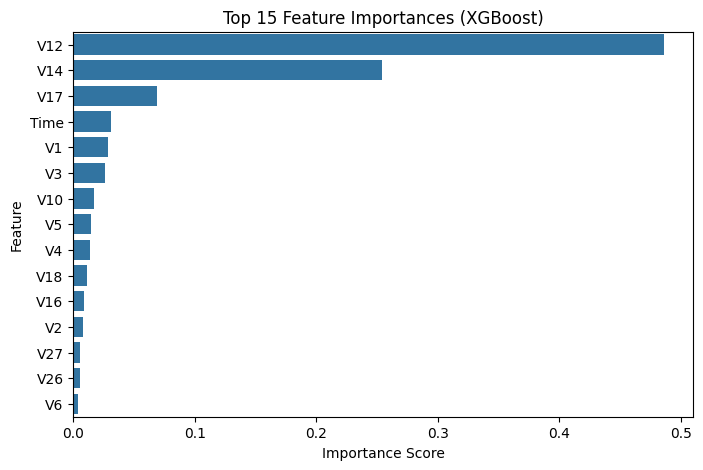

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance = best_model.feature_importances_

feature_names = df.drop("Class", axis=1).columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).head(15)

plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df
)

plt.title("Top 15 Feature Importances (XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

**Final Comparison:**

In [16]:
print("Sampling Techniques Comparison\n")
display(sampling_results_df)

print("\nEnsemble Models Comparison\n")
display(ensemble_results_df)

Sampling Techniques Comparison



,Technique,Precision,Recall,F1-score,Training Time
0,Random Oversampling,0.184783,0.809524,0.300885,0.823048
1,Random Undersampling,0.156522,0.857143,0.264706,0.091502
2,SMOTE,0.202532,0.761905,0.320000,0.872054
3,Tomek Links,0.521739,0.571429,0.545455,6.898401



Ensemble Models Comparison



,Model,Precision,Recall,F1-score,Training Time
0,Random Forest,0.937500,0.714286,0.810811,29.820091
1,Gradient Boosting,0.833333,0.714286,0.769231,66.808127
2,XGBoost,0.888889,0.761905,0.820513,1.251234
3,Stacking Classifier,0.937500,0.714286,0.810811,371.260335


**Is SMOTE always better? Why?**

No, SMOTE is not always better.
It creates synthetic samples for the minority class which can improve recall. However, it may also generate noisy or unrealistic samples and sometimes increase overfitting if the dataset is very small.


**Does Oversampling increase overfitting risk?**

Yes,
Random oversampling duplicates minority samples, which may cause the model to memorize these examples instead of learning general patterns, leading to overfitting.


**Why is PR Curve more informative than ROC in imbalanced datasets?**


In imbalanced datasets, ROC curves may look optimistic because the majority class dominates the data.
The Precision–Recall curve focuses on the minority class performance (precision and recall), making it more informative for problems like fraud detection.


**How do Tomek Links improve decision boundaries?**


Tomek Links identify pairs of samples from different classes that are very close to each other.
Removing the majority class sample from these pairs reduces class overlap and helps create clearer decision boundaries.


**Which ensemble method performed best and why?**



The best-performing model was XGBoost.
It achieved the highest F1-score and recall while also having the fastest training time, making it the most efficient model for fraud detection in this experiment.
